In this analysis of eviction data, land-use data was imported to facilitate an examination of the number of eviction cases and the categories of buildings in which evictions occurred. Number of final sample included 114,590 executed evictions with valid BBL only(10-digit unique identifier of property, stands for Borough-Block-Lot).

In [117]:
# load package and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#save dataframe to df1
df1= pd.read_csv('https://data.cityofnewyork.us/resource/6z8x-wfk4.csv?$limit=150000')
pd.set_option('display.max_columns', None)#display all columns
df1.head()

,court_index_number,docket_number,eviction_address,eviction_apt_num,executed_date,marshal_first_name,marshal_last_name,residential_commercial_ind,borough,eviction_zip,ejectment,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta
0,323578/23A,124166,1140-1150 ANDERSON A VENUE,A-21,2024-10-01T00:00:00.000,Justin,Grossman,Residential,BRONX,10452,Not an Ejectment,Possession,40.835606,-73.924605,4.0,16.0,199.0,2003069.0,2.025050e+09,Highbridge
1,K93173/16,75476,339 48TH STREET,2,2017-06-13T00:00:00.000,Ileana,Rivera,Residential,BROOKLYN,11220,Not an Ejectment,Possession,40.648257,-74.012497,7.0,38.0,80.0,3012197.0,3.007640e+09,Sunset Park West
2,57462/18,205579,1655 FLATBUSH AVENUE,C1210,2018-10-17T00:00:00.000,Richard,Capuano,Residential,BROOKLYN,11210,Not an Ejectment,Possession,40.630096,-73.944757,18.0,45.0,776.0,3206459.0,3.075790e+09,Flatlands
3,K303363/23,415018,1620 FULTON STREET,5D ALL ROOMS,2023-12-04T00:00:00.000,Richard,McCoy,Residential,BROOKLYN,11213,Not an Ejectment,Possession,40.679648,-73.936048,3.0,36.0,271.0,3000000.0,3.016990e+09,Crown Heights North
4,328454/24,36854,1212 UNIVERSITY AVE,3-D,2025-09-09T00:00:00.000,Gary,Rose,Residential,BRONX,10452,Not an Ejectment,Possession,40.838281,-73.927269,4.0,16.0,199.0,2116375.0,2.025280e+09,Highbridge


In [118]:
#check number of rows missing values
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127898 entries, 0 to 127897
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   court_index_number          127898 non-null  object 
 1   docket_number               127898 non-null  int64  
 2   eviction_address            127898 non-null  object 
 3   eviction_apt_num            109189 non-null  object 
 4   executed_date               127898 non-null  object 
 5   marshal_first_name          127898 non-null  object 
 6   marshal_last_name           127898 non-null  object 
 7   residential_commercial_ind  127898 non-null  object 
 8   borough                     127898 non-null  object 
 9   eviction_zip                127898 non-null  int64  
 10  ejectment                   127898 non-null  object 
 11  eviction_possession         127898 non-null  object 
 12  latitude                    116496 non-null  float64
 13  longitude     

In [131]:
#change datatypes to string
df1[['community_board','council_district','bin', 'bbl']] = df1[['community_board','council_district',
                           'bin', 'bbl']].astype('str')

In [132]:
#the number of executed evictions in each borough
df1['borough'].value_counts()

,count
borough,
BRONX,38387
BROOKLYN,31940
QUEENS,22529
MANHATTAN,19335
STATEN ISLAND,3861


In [4]:
#Rename the variables KINGS, RICHMOND, and NEW YORK to their uniform borough names
df1['borough'] = df1['borough'].replace({'KINGS': 'BROOKLYN',
                                         'RICHMOND': 'STATEN ISLAND',
                                         'NEW YORK':'MANHATTAN' })

In [ ]:
#Export df1 as a spreadsheet for graphing in Tableau.
from google.colab import files
df1.to_csv('eviction.csv', index=False)
files.download('eviction.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Export .csv and graph the count of execucted evictions trend in Tableau

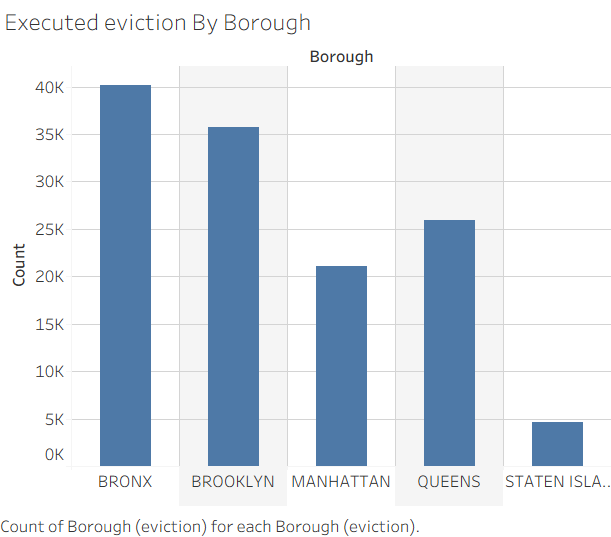

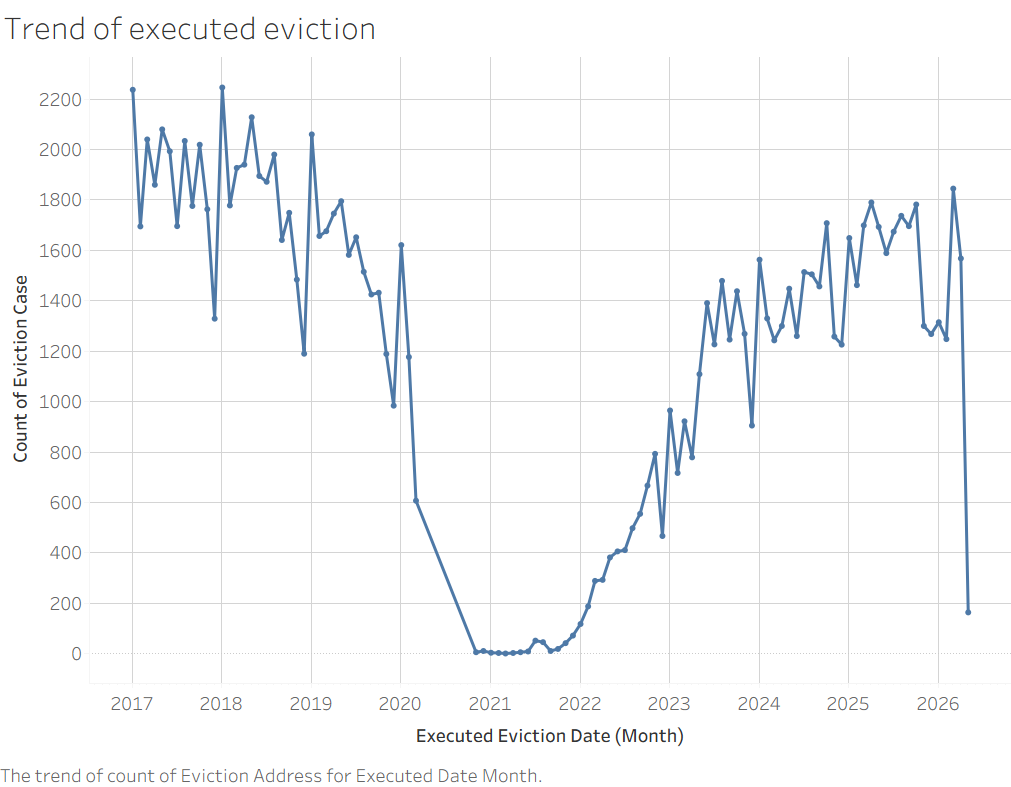

The Bronx has the highest number of evictions, followed by Brooklyn and Queens. The number of evictions dropped during COVID-19 and increased after the pandemic.

In [125]:
# To merge the eviction data with the building data, drop rows that contain NaN values in the bbl column.
df1 = df1.dropna(subset = ['bbl'])

In [ ]:
#remove unwanted variables
df1 = df1.drop(columns=['court_index_number','ejectment',
                        'eviction_apt_num','eviction_possession','census_tract'])

In [133]:
#115,684 rows remain after dropping NaN values (as of 5/7/26).
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116052 entries, 0 to 127897
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   docket_number               116052 non-null  int64  
 1   eviction_address            116052 non-null  object 
 2   executed_date               116052 non-null  object 
 3   marshal_first_name          116052 non-null  object 
 4   marshal_last_name           116052 non-null  object 
 5   residential_commercial_ind  116052 non-null  object 
 6   borough                     116052 non-null  object 
 7   eviction_zip                116052 non-null  int64  
 8   latitude                    116052 non-null  float64
 9   longitude                   116052 non-null  float64
 10  community_board             116052 non-null  object 
 11  council_district            116052 non-null  object 
 12  bin                         116052 non-null  object 
 13  bbl                

import "Primary Land Use Tax Lot Output (PLUTO)" from NYC OpenData.
It contains data of buildings in NYC(e.g. building class, land use, no. of residential unit, ownername, BBL... )
File size exceeds 400MB, contains 101 cols, I downloaded file and removed >90 columns, then uploaded and shared in GoogleDrive

In [192]:
#import and save data frame to df0
df0 = pd.read_csv("https://drive.google.com/uc?id=128Vol9PIo9zE1lCaM_xKUfL1luWC1YyX", low_memory=False)
df0.head()

,bldgclass,landuse,ownername,numfloors,unitsres,yearbuilt,BBL,latitude,longitude
0,A5,1.0,"LIU, RUI TANG",2.00,1,1950.0,4061730023,40.769090,-73.772074
1,A0,1.0,3512 STONE LLC,1.67,1,1945.0,4061730024,40.768889,-73.772150
2,B3,1.0,"DRAKOULIAS, E PETER",2.50,2,1915.0,4061690026,40.767995,-73.773987
3,C9,2.0,BAYSIDE GARDENS NY LLC,2.00,36,1957.0,4061720001,40.767116,-73.773521
4,C1,2.0,"36-08 BELL REALTY,",3.00,36,1955.0,4061720006,40.767555,-73.773375


In [193]:
#check number of NaN values
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858644 entries, 0 to 858643
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   bldgclass  858320 non-null  object 
 1   landuse    855931 non-null  float64
 2   ownername  857809 non-null  object 
 3   numfloors  816281 non-null  float64
 4   unitsres   858199 non-null  object 
 5   yearbuilt  858318 non-null  float64
 6   BBL        858644 non-null  int64  
 7   latitude   857161 non-null  float64
 8   longitude  857161 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 59.0+ MB


In [194]:
#drop NaN values in 'BBL'column
df0 = df0.dropna(subset = ['BBL'])

In [195]:
#convert datatype to string
df0['BBL'] = df0['BBL'].astype('str')

In [196]:
#Rename the "BBL" column in df0 to match the bbl column name in df1
df0 = df0.rename(columns={
    'BBL':'bbl'})

In [197]:
#Further cleaning: continue dropping unwanted columns.
df0 = df0.drop(columns=['latitude', 'longitude','landuse','numfloors'])
df0.head()

,bldgclass,ownername,unitsres,yearbuilt,bbl
0,A5,"LIU, RUI TANG",1,1950.0,4061730023
1,A0,3512 STONE LLC,1,1945.0,4061730024
2,B3,"DRAKOULIAS, E PETER",2,1915.0,4061690026
3,C9,BAYSIDE GARDENS NY LLC,36,1957.0,4061720001
4,C1,"36-08 BELL REALTY,",36,1955.0,4061720006


In [198]:
#Merge the datasets using a left join (keeping all rows from the left table and matched rows from the right table), and save the result to df.
df=df1.merge(df0, on='bbl', how='left')
df.head()

,docket_number,eviction_address,executed_date,marshal_first_name,marshal_last_name,residential_commercial_ind,borough,eviction_zip,latitude,longitude,community_board,council_district,bin,bbl,nta,bldgclass,ownername,unitsres,yearbuilt
0,124166,1140-1150 ANDERSON A VENUE,2024-10-01T00:00:00.000,Justin,Grossman,Residential,BRONX,10452,40.835606,-73.924605,4.0,16.0,2003069,2025050050,Highbridge,D7,1150 REALTY LLC,92,1927.0
1,75476,339 48TH STREET,2017-06-13T00:00:00.000,Ileana,Rivera,Residential,BROOKLYN,11220,40.648257,-74.012497,7.0,38.0,3012197,3007640059,Sunset Park West,B9,"SANABRIA, EVA",2,1910.0
2,205579,1655 FLATBUSH AVENUE,2018-10-17T00:00:00.000,Richard,Capuano,Residential,BROOKLYN,11210,40.630096,-73.944757,18.0,45.0,3206459,3075790010,Flatlands,D4,PHILIP HOWARD APARTMENTS TENANTS CP,634,1964.0
3,415018,1620 FULTON STREET,2023-12-04T00:00:00.000,Richard,McCoy,Residential,BROOKLYN,11213,40.679648,-73.936048,3.0,36.0,3000000,3016990033,Crown Heights North,NaN,NaN,NaN,NaN
4,36854,1212 UNIVERSITY AVE,2025-09-09T00:00:00.000,Gary,Rose,Residential,BRONX,10452,40.838281,-73.927269,4.0,16.0,2116375,2025280011,Highbridge,D1,BEULAH CLUSTER HOUSING DEVELOPMENT FUND COMPANY,54,2005.0


In [199]:
#After merging, check for missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116052 entries, 0 to 116051
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   docket_number               116052 non-null  int64  
 1   eviction_address            116052 non-null  object 
 2   executed_date               116052 non-null  object 
 3   marshal_first_name          116052 non-null  object 
 4   marshal_last_name           116052 non-null  object 
 5   residential_commercial_ind  116052 non-null  object 
 6   borough                     116052 non-null  object 
 7   eviction_zip                116052 non-null  int64  
 8   latitude                    116052 non-null  float64
 9   longitude                   116052 non-null  float64
 10  community_board             116052 non-null  object 
 11  council_district            116052 non-null  object 
 12  bin                         116052 non-null  object 
 13  bbl           

In [200]:
#convert variable 'yearbuilt' to integar
df['yearbuilt'] = df['yearbuilt'].astype('Int64')

In [201]:
#drop missing value in 'yearbuilt' column.
df = df.dropna(subset = ['yearbuilt'])

In [202]:
#114,940 rows remain after removing missing values in the yearbuilt column. (as of 5/14/26)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114940 entries, 0 to 116051
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   docket_number               114940 non-null  int64  
 1   eviction_address            114940 non-null  object 
 2   executed_date               114940 non-null  object 
 3   marshal_first_name          114940 non-null  object 
 4   marshal_last_name           114940 non-null  object 
 5   residential_commercial_ind  114940 non-null  object 
 6   borough                     114940 non-null  object 
 7   eviction_zip                114940 non-null  int64  
 8   latitude                    114940 non-null  float64
 9   longitude                   114940 non-null  float64
 10  community_board             114940 non-null  object 
 11  council_district            114940 non-null  object 
 12  bin                         114940 non-null  object 
 13  bbl                

In [204]:
#Convert the data type 'yearbuilt' to string and save into new column for descriptive statistics.
df['yearbuilt_str'] = df['yearbuilt'].astype(str)

In [205]:
#Summarize string/object columns: include row count, number of unique values, most frequent value, and its frequency.
#building class D1 dominates the dataset, heavily residential/apartment-focused
#There are 200 distinct construction years. The most common value is 1920, which appears 6,880 times.
#The most frequent bbl is 2028820229, which appears 369 times.
df.describe(include=['object'])

,eviction_address,executed_date,marshal_first_name,marshal_last_name,residential_commercial_ind,borough,community_board,council_district,bin,bbl,nta,bldgclass,ownername,unitsres,yearbuilt_str
count,114940,114940,114940,114940,114940,114940,114940,114940,114940,114940,114940,114940,114940,114940,114940
unique,61144,1926,27,30,2,5,18,51,48023,45305,191,145,40079,718,200
top,20 RICHMAN PLAZA,2017-01-18T00:00:00.000,Justin,Grossman,Residential,BRONX,12.0,15.0,3000000,2028820229,Central Harlem North-Polo Grounds,D1,NYC HOUSING AUTHORITY,2,1920
freq,116,160,21127,21127,107638,38087,12719,6509,317,369,2549,19260,3060,14257,6880


In [215]:
#The property with the most frequent bbl value, 2028820229, is a development.
df[df['bbl'] == '2028820229']['eviction_address'].unique()

array(['20 RICHMAN PLAZA', '40 RICHMAN PLAZA', '10 RICHMAN PLAZA',
       '30 RICHMAN PLAZA', '40 RICHMOND PLAZA', '16 RICHMAN PLAZA'],
      dtype=object)

bldgclass
D1    19260
C1    18693
C7     8425
D7     7255
D3     6441
C0     5985
D4     4242
B2     4150
Name: unitsres, dtype: int64


<Axes: title={'center': 'Top 8 Building Types with the Most Evictions'}, xlabel='Building Class', ylabel='Count'>

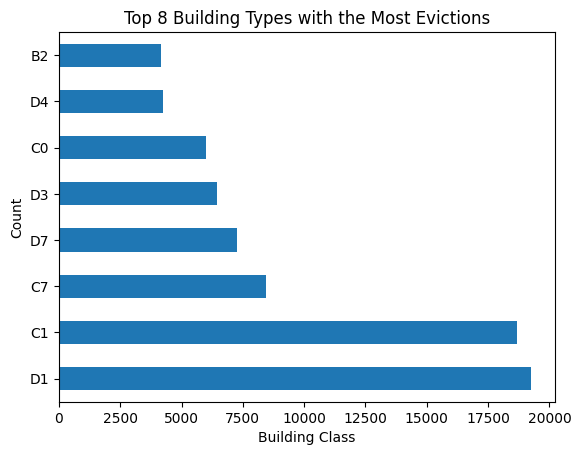

In [216]:
#building types experience the highest number of executed evictions in NYC
building_class = df.groupby('bldgclass')['unitsres'].count().sort_values(
    ascending=False).head(8)
print(building_class)

building_class.plot(
        kind='barh',
        title='Top 8 Building Types with the Most Evictions',
        ylabel='Count',
        xlabel='Building Class')

D1: Multi-Family Elevator apts; Semi-fireproof (no stores)

C1: Multi-Family Walk-Up Buildings, no store (7+ units)

C7: Mixed Residential & Commercial Buildings(7+ units)

D7: Mixed Residential & Commercial Buildings, Semi-Fireproof

D3, D4: Multi-Family Elevator Buildings. D4:Elevator Cooperatives, residents own shares.

C0: 3-Family Walk-Up Buildings

B2: One & Two Family Buildings

Source: NYC Building Classifications - DOF. https://www.nyc.gov/assets/finance/jump/hlpbldgcode.html




In [207]:
#Percentage of all evictions do the top 5 building types account for?

top5_bldg = building_class.head(5).sum()/df.shape[0]*100 #returns the number of rows in df

print(f'Top 5 building types account for {top5_bldg:.2f}% of all evictions')


Top 5 building types account for 52.27% of all evictions


Percentage of all evictions do the top 5 building types account for?

---


Executed evictions are concentrated within a limited set of NYC building types.


yearbuilt
1920    6880
1931    6816
1930    6559
1910    5942
1925    4695
1927    4049
1928    3831
1926    3054
1950    2759
1929    2502
dtype: int64


Text(0, 0.5, 'Year Built')

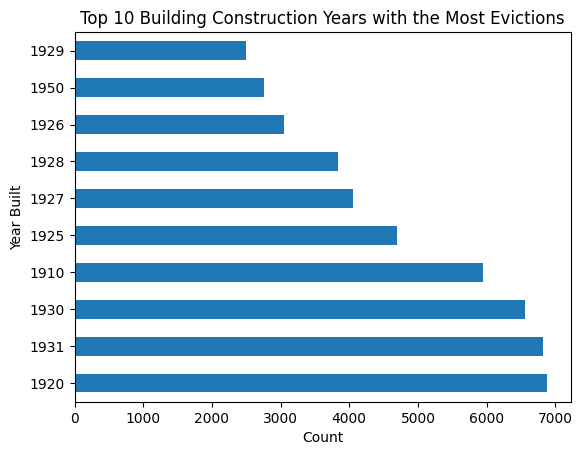

In [208]:
##Percentage of all evictions do the top 5 building construction year account for?
df['yearbuilt'] = df['yearbuilt'].astype(str).str.split('.').str[0]
yrbuilt = df.groupby('yearbuilt').size().sort_values(
    ascending=False).head(10) #size() returns the product of rows and columns, total number of rows each unique year
print(yrbuilt)

yrbuilt.plot(kind='barh', title='Top 10 Building Construction Years with the Most Evictions')
plt.xlabel('Count')
plt.ylabel('Year Built')

In [209]:
#Percentage of all evictions do the top 5 building construction year account for?
top5_yearbuilt = yrbuilt.head(8).sum()/df.shape[0]*100 #returns the number of rows in df

print(f'Top 8 construction year account for {top5_yearbuilt:.2f}% of all evictions')

Top 8 construction year account for 36.39% of all evictions



Executed evictions are concentrated in buildings constructed before 1950.

1-2      34777
3-5       6753
6-10      2495
11-20      911
21+        369
Name: count, dtype: int64


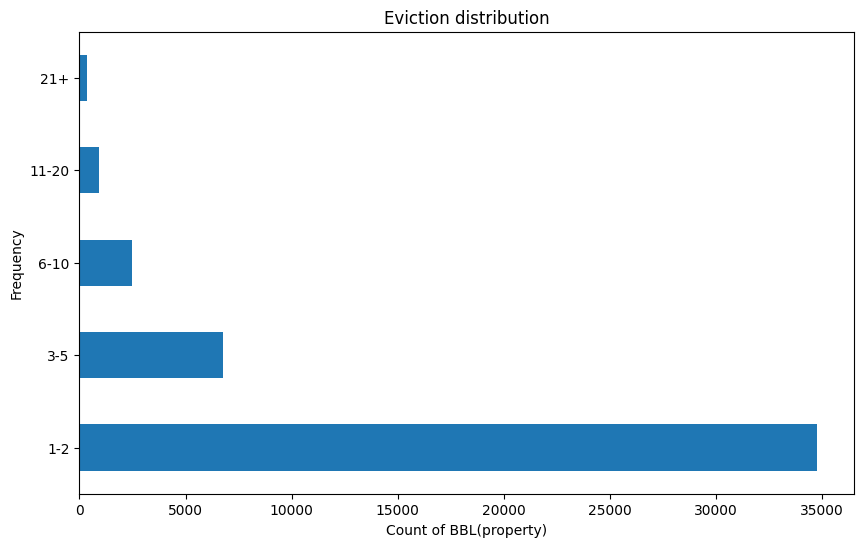

In [210]:
#Eviction distribution
bbl_counts = df.groupby('bbl').size()

bins = [0, 2, 5, 10, 20, float('inf')]
labels = ['1-2', '3-5', '6-10', '11-20', '21+']

#
binned_counts = pd.cut(bbl_counts, bins=bins, labels=labels)
frequency = binned_counts.value_counts().sort_index()
print(frequency)
#
plt.figure(figsize=(10,6))
frequency.plot(kind='barh',
               title = 'Eviction distribution')

plt.xlabel('Count of BBL(property)')
plt.ylabel('Frequency')
plt.show()

